In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split

In [35]:
metrics = pd.read_csv('D:/cse/SEM5/INT234/Project/results/model_metrics.csv')
print(metrics)


                        model       auc  precision    recall        f1
0            Linear_noScaling  0.903603   0.790598  0.192909  0.310142
1               Linear_Scaled  0.591594   0.790598  0.192909  0.310142
2            Logistic_noSMOTE  0.827757   0.473841  0.831074  0.603559
3              Logistic_SMOTE  0.768673   0.539947  0.641293  0.586273
4            Logistic_noSMOTE  0.827757   0.473841  0.831074  0.603559
5  Random_Forest(classWeight)  0.815994   0.506467  0.775808  0.612850
6        Random_Forest(Smote)  0.815994   0.506467  0.775808  0.612850
7                    LightGBM  0.906421   0.638725  0.564129  0.599114
8                   XGB_SMOTE  0.902579   0.619590  0.567258  0.592270


In [36]:
df = pd.read_csv(r"D:\cse\SEM5\INT234\Project\model_ready.csv")

In [37]:
X = df.drop(columns=['is_productive','is_healthy'], errors='ignore')
y = df['is_productive']

In [38]:
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [39]:
import joblib

In [50]:

lr_model = joblib.load(r"D:\cse\SEM5\INT234\Project\models\logreg_sm.pkl")

rf_model = joblib.load(r"D:\cse\SEM5\INT234\Project\models\rf_smote.pkl")

xgb_model =joblib.load(r"D:\cse\SEM5\INT234\Project\models\xgb_smote.pkl")

Lgbm_model  = joblib.load(r"D:\cse\SEM5\INT234\Project\models\lgbm_smote.pkl")
print(type(Lgbm_model))

<class 'lightgbm.sklearn.LGBMClassifier'>


c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


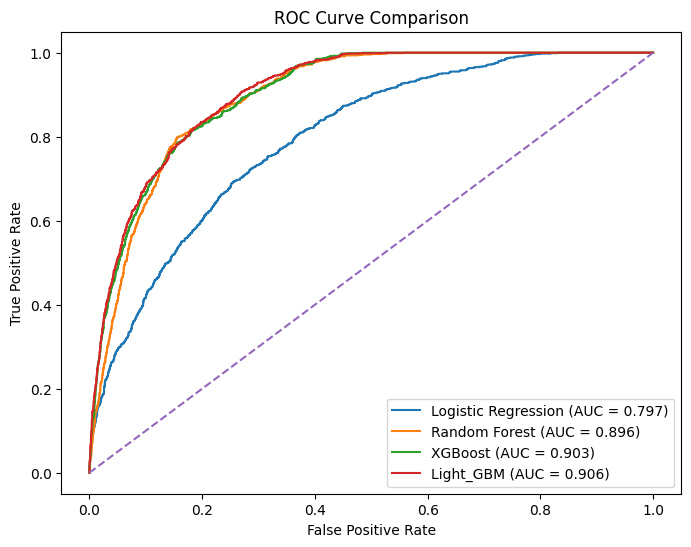

In [52]:
model_probs = {
    'Logistic Regression' : lr_model.predict_proba(X_val)[:,1],
    'Random Forest': rf_model.predict_proba(X_val)[:,1],
    'XGBoost': xgb_model.predict_proba(X_val)[:,1],
    'Light_GBM': Lgbm_model.predict_proba(X_val)[:,1]
}

plt.figure(figsize=(8,6))

for model_name, probs in model_probs.items():
    fpr, tpr, _ = roc_curve(y_val, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


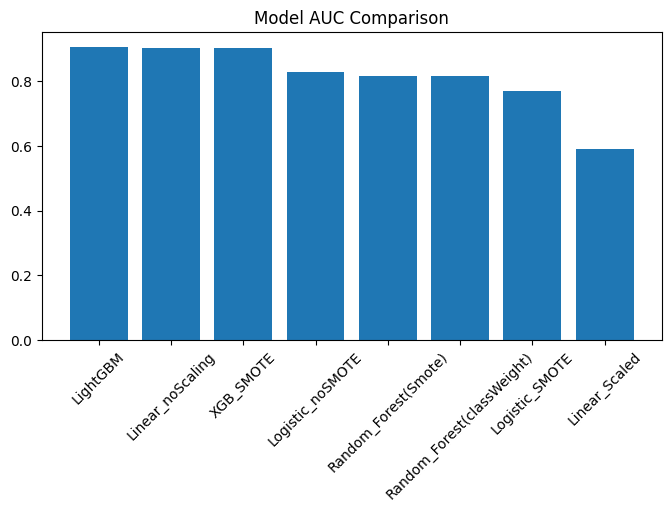

In [53]:
# Simple bar chart of AUC
plt.figure(figsize=(8,4))
metrics = metrics.sort_values('auc', ascending=False)
plt.bar(metrics['model'], metrics['auc'])
plt.xticks(rotation=45)
plt.title('Model AUC Comparison')
plt.show()

In [54]:
# Print best model
best = metrics.sort_values('auc', ascending=False).iloc[0]
print('Best model by AUC:', best['model'], 'AUC:', best['auc'])

Best model by AUC: LightGBM AUC: 0.906421153
